In [1]:
%load_ext autoreload
%autoreload 2

import pathlib
import sys
project_root = pathlib.Path.cwd().parent / 'Python'
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import ISRUtilities as isru
import modelsCNN as models

import numpy as np
import fmatoolbox as fma
import torch
import sklearn as sk
import joblib

froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
session = fma.data.readBatchFile(batch_file)[0][8]
print(session)

/mnt/hubel-data-131/perceval/Rat003_20231223/Rat003_20231223.xml


In [3]:
def couplData(session,regs,lim=[-0.25,0.25],delay=0,return_t=False):

    R = fma.regions.regions(session,load_spikes=False)
    channels = np.sort(R.channels(regs))
    events = isru.loadHpcPfcEvents(session)

    # random distances from delta peak time (some probably too far to capture)
    rng = np.random.default_rng()
    distance = rng.normal(loc=delay,scale=0.1,size=len(events['deltaWaves']))
    centers = events['deltaWaves'] - distance

    # load data around delta waves
    data, t = fma.data.loadWideband(session,channels=channels,intervals=centers[:,None]+lim,cat=False)
    n_samples = min([len(d) for d in data])
    data = np.stack([d[:n_samples].T for d in data],axis=0) # (events, channels, time)
    t = np.stack([d[:n_samples] for d in t],axis=0) # (events, time)

    if return_t:
        return data, distance, t
    return data, distance

In [20]:
X, y, t = couplData(session,'pfc',delay=0.,return_t=True)

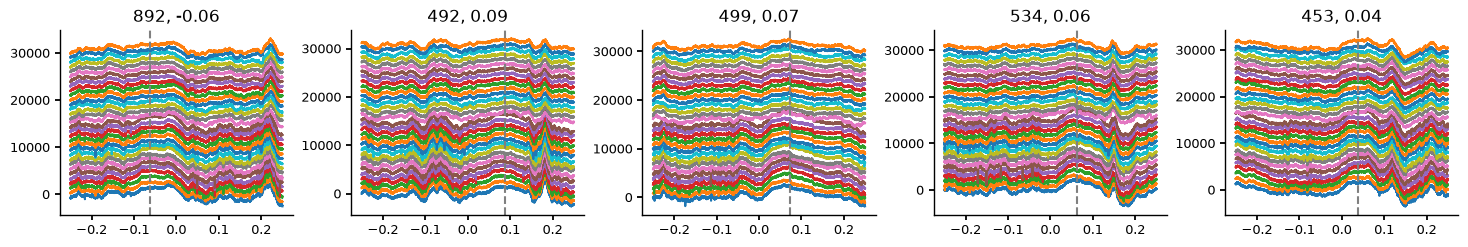

In [21]:
# see delta waves
fig, ax = fma.plotting.makeFigure(n=(1,5),size=(37,6))
for i, j in enumerate(np.random.randint(0,X.shape[0],5)):
    time = t[j] - t[j][0] - (t[j][-1] - t[j][0]) / 2
    ax[i].plot(time,X[j].T+np.arange(X.shape[1])*1000)
    ax[i].axvline(y[j],ls='--',color='gray')
    ax[i].set(title=f'{j}, {y[j]:.2f}')

Predict delta wave peak

In [ ]:
def _couplingPLSR(session,regs,delay=0,n_components=5):
    # compute learning curve for regression on wideband data

    X, y = couplData(session,regs,delay=delay)
    X = X.reshape(X.shape[0],-1) # (events, channels * time)

    model = sk.pipeline.Pipeline([
            ("plsr", sk.cross_decomposition.PLSRegression(n_components=n_components)), # (previous test shows that ~70 PCs explain 95% of the variance)
            ])
    train_sizes_abs, train_scores, test_scores = sk.model_selection.learning_curve(model,X,y,scoring="r2",verbose=1)
    results = {"model": model,
               "train_sizes": train_sizes_abs,
               "train_scores": train_scores,
               "test_scores": test_scores,}
    name = regs if (isinstance(regs,str) or len(regs)) == 1 else '_'.join(regs)
    joblib.dump(results, f"Results/SimplerProblem/PLSR_c{n_components}_d{delay}_{name}.joblib")

    return results

In [ ]:
pls_cv = _couplingPLSR(session,regs='pfc',delay=0.1)
pls_cv = _couplingPLSR(session,regs='hpc',delay=0)
pls_cv = _couplingPLSR(session,regs='hpc',delay=0.1)

[learning_curve] Training set sizes: [ 72 235 398 561 725]


[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:  1.6min finished


<class 'str'>
pfc
[learning_curve] Training set sizes: [ 72 235 398 561 725]


In [ ]:
def _couplingCNN(session,regs,model="CNN1d",train_sizes=None,rnd_seed=None):

    # configure GPU use
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"device: {device}")

    X, y = couplData(session,regs)
    X = torch.tensor(X,dtype=torch.float32)
    y = torch.tensor(y,dtype=torch.float32)

    mod = model # store model name
    kf = sk.model_selection.KFold(n_splits=5,shuffle=True,random_state=rnd_seed)
    kf = kf.split(X)
    train_losses = []
    test_losses = []
    val_losses = []
    print("fold  -  validation Huber loss")
    for fold, (train_idx, val_idx) in enumerate(kf):
        if train_sizes is None: train_sizes = [len(train_idx)]
        print(f"  {fold+1}   -",end="")

        train_losses.append([])
        test_losses.append([])
        val_losses.append([])
        for n in train_sizes:
            this_train_idx = train_idx[:n]

            # split into train and validation sets
            X_train = X[this_train_idx]
            y_train = y[this_train_idx]
            X_val = X[val_idx]
            y_val = y[val_idx]

            # normalize
            m = X_train.mean(dim=(0,2),keepdim=True)
            s = X_train.std(dim=(0,2),keepdim=True)
            X_train = (X_train - m) / s
            X_val = (X_val - m) / s

            # repeat data for epochs
            train_ds = torch.utils.data.TensorDataset(X_train,y_train)
            val_ds = torch.utils.data.TensorDataset(X_val,y_val)
            train_loader = torch.utils.data.DataLoader(train_ds,batch_size=16,shuffle=True)
            val_loader = torch.utils.data.DataLoader(val_ds,batch_size=16,shuffle=False)

            # define / reset model
            model = models.loadModel(mod,n_features=X.shape[1]).to(device)
            optimizer = torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4) # weight_decay against overfitting
            #criterion = torch.nn.MSELoss()
            criterion = torch.nn.HuberLoss() # better for nonnegative target

            # training
            for epoch in range(100):
                model.train()
                for xb, yb in train_loader:
                    xb = xb.to(device)
                    yb = yb.to(device)
                    optimizer.zero_grad()
                    pred = model(xb)
                    loss = criterion(pred,yb)
                    loss.backward()
                    optimizer.step()

            # evaluate train
            model.eval()
            y_true = []
            y_pred = []
            with torch.no_grad():
                for xb, yb in train_loader:
                    y_true.append(yb.numpy())
                    xb = xb.to(device)
                    pred = model(xb)
                    y_pred.append(pred.cpu().detach().numpy())
            train_losses[-1].append(sk.metrics.r2_score(np.concatenate(y_true), np.concatenate(y_pred)))

            # evaluate test
            y_true = []
            y_pred = []
            this_val_losses = []
            with torch.no_grad():
                for xb, yb in val_loader:
                    y_true.append(yb.numpy())
                    xb = xb.to(device)
                    yb = yb.to(device)
                    pred = model(xb)
                    loss = criterion(pred,yb)
                    this_val_losses.append(loss.item())
                    y_pred.append(pred.cpu().detach().numpy())
            test_losses[-1].append(sk.metrics.r2_score(np.concatenate(y_true), np.concatenate(y_pred)))

        mean_val_loss = np.mean(this_val_losses)
        print(f"  {mean_val_loss:.4f}")
        val_losses[-1].append(mean_val_loss.item())

        results = {"train_sizes": train_sizes,
                   "train_scores": train_losses,
                   "test_scores": test_losses,
                   "val_losses": val_losses}
        joblib.dump(results, f"Results/SimplerProblem/{mod}_{'_'.join(regs)}.joblib")

    return results

In [6]:
pls_cv = joblib.load("Results/SimplerProblem/PLSR.joblib")
CNN_cv = _couplingCNN(session,'pfc',model='CNN1d',train_sizes=pls_cv['train_sizes'],rnd_seed=42)

NameError: name '_couplingCNN' is not defined

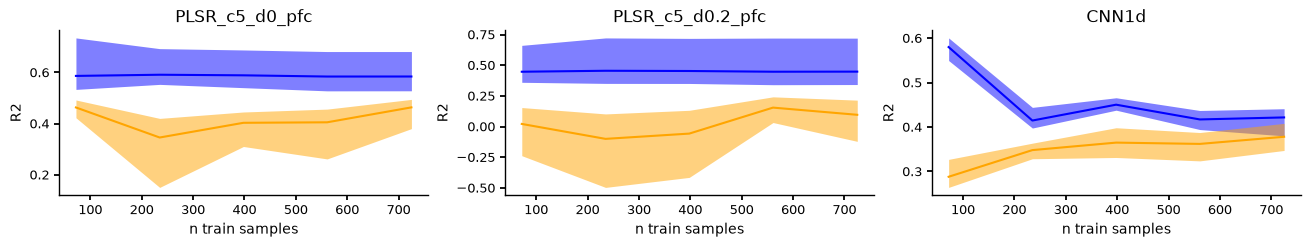

In [ ]:
names = ['PLSR_c5_d0_pfc','PLSR_c5_d0.1_pfc','PLSR_c5_d0.2_pfc','PLSR_c5_d0_hpc','PLSR_c5_d0.1_hpc','CNN1d']
fig, ax = fma.plotting.makeFigure(n=(1,len(names)),size=(33,6))
for i, name in enumerate(names):
    res = joblib.load(f"Results/SimplerProblem/{name}.joblib")
    fma.plotting.semPlot(res["train_sizes"],res["train_scores"],color='b',ax=ax[i])
    fma.plotting.semPlot(res["train_sizes"],res["test_scores"],color='orange',ax=ax[i])
    ax[i].set(xlabel='n train samples',ylabel='R2',title=name)